# Написание всех функций для пайплайна

## Инициализация моделей

Простосто импорт библиотек и скачивание весов

In [ ]:
!pip install facenet-pytorch -q

import os
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import transforms
from facenet_pytorch import MTCNN

os.makedirs('weights', exist_ok=True)

print("--- Скачивание весов моделей из облака ---")

!gdown --id 13fJmGe6VQlk2Tfk9zZ-7zlDtkkhPUosS -O weights/hourglass_best.pth

!gdown --id 1ERcn8yOxfrEUyP80dAZM0dhEDlt5gi72 -O weights/arcface_best.pth

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Настройка завершена. В качестве device выбран: {device}")

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


--- Скачивание весов моделей из облака ---
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=13fJmGe6VQlk2Tfk9zZ-7zlDtkkhPUosS
To: /content/weights/hourglass_best.pth
100% 7.05M/7.05M [00:00<00:00, 134MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ERcn8yOxfrEUyP80dAZM0dhEDlt5gi72
To: /content/weights/arcface_best.pth
100% 5.76M/5.76M [00:00<00:00, 37.7MB/s]

[INFO] Настройка завершена. В качестве device выбран: cpu


Ниже будут обьявлены классы для обученных мною моделей. Более подробное объяснение по архитектуре вы можете посмотреть в ноутбуках stage_2 и stage_3.

Здесь я вскользь поясню, что Stacked Hourglass Network написана на основе двух Hourglass блоков, а так же принимает изображения формата 256*256.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)

class Hourglass(nn.Module):
    def __init__(self, depth, num_channels):
        super().__init__()
        self.depth = depth

        self.up_residual = ResidualBlock(num_channels, num_channels)

        self.downsample = nn.MaxPool2d(kernel_size=2, stride=2)
        self.down_residual = ResidualBlock(num_channels, num_channels)

        if self.depth > 1:
            self.inner_hg = Hourglass(depth - 1, num_channels)
        else:
            self.inner_hg = ResidualBlock(num_channels, num_channels)

        self.post_inner_residual = ResidualBlock(num_channels, num_channels)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        up_features = self.up_residual(x)

        down = self.downsample(x)
        down = self.down_residual(down)
        inner = self.inner_hg(down)

        up = self.post_inner_residual(inner)
        up = self.upsample(up)

        return up_features + up


class StackedHourglassNet(nn.Module):
    def __init__(self, num_stacks=2, num_channels=128, num_classes=5):
        super().__init__()
        self.num_stacks = num_stacks

        self.pre_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResidualBlock(64, 128),
            nn.MaxPool2d(kernel_size=2, stride=2),
            ResidualBlock(128, num_channels)
        )

        self.hg_blocks = nn.ModuleList()
        self.res_blocks = nn.ModuleList()
        self.fc_blocks = nn.ModuleList()
        self.score_heads = nn.ModuleList()
        self.merge_preds = nn.ModuleList()
        self.merge_feats = nn.ModuleList()

        for i in range(num_stacks):
            self.hg_blocks.append(Hourglass(depth=4, num_channels=num_channels))

            self.res_blocks.append(ResidualBlock(num_channels, num_channels))
            self.fc_blocks.append(nn.Sequential(
                nn.Conv2d(num_channels, num_channels, kernel_size=1),
                nn.BatchNorm2d(num_channels),
                nn.ReLU(inplace=True)
            ))

            self.score_heads.append(nn.Conv2d(num_channels, num_classes, kernel_size=1))

            if i < num_stacks - 1:
                self.merge_preds.append(nn.Conv2d(num_classes, num_channels, kernel_size=1))
                self.merge_feats.append(nn.Conv2d(num_channels, num_channels, kernel_size=1))

    def forward(self, x):
        x = self.pre_conv(x)

        outputs = []
        for i in range(self.num_stacks):
            hg = self.hg_blocks[i](x)
            res = self.res_blocks[i](hg)
            fc = self.fc_blocks[i](res)

            score = self.score_heads[i](fc)
            outputs.append(score)

            if i < self.num_stacks - 1:
                fc_ = self.merge_feats[i](fc)
                score_ = self.merge_preds[i](score)
                x = x + fc_ + score_

        return outputs

print("Архитектура Stacked Hourglass Network успешно скомпилирована!")

Архитектура Stacked Hourglass Network успешно скомпилирована!


In [ ]:
model_hourglass = StackedHourglassNet(num_stacks=2, num_channels=128, num_classes=5)

try:
    hourglass_checkpoint = torch.load('weights/hourglass_best.pth', map_location=device)
    # Если сохранялся весь чекпоинт со state_dict, берем его, иначе загружаем напрямую
    if isinstance(hourglass_checkpoint, dict) and 'model_state_dict' in hourglass_checkpoint:
        model_hourglass.load_state_dict(hourglass_checkpoint['model_state_dict'])
    else:
        model_hourglass.load_state_dict(hourglass_checkpoint)

    model_hourglass = model_hourglass.to(device)
    model_hourglass.eval() # Переводим в режим инференса (отключаем dropout/batchnorm)
    print("[ОК] Веса Stacked Hourglass Network успешно загружены.")
except Exception as e:
    print(f"[ОШИБКА] Не удалось загрузить веса Hourglass: {e}")

[ОК] Веса Stacked Hourglass Network успешно загружены.


Как сеть для получения эмбейдингов взята обученая мною свёрточная сеть на основе ArcFace. Так как я старался сохранить бизнес логику, я собрал небольшой датасет - 700 человек(условные сотрудники) и по +-19 изображений(обучение шло только на 15).

В следствии особенности датасета, я не смог обучить модель основанную на ImageNet, так как переобучался. Как решение мною наисана кастомная, легковесная нейросеть, обученная на CEloss а уже после этого я дообучил ее с использованием ArcFace.

На вход подаётся изображение 224*224, полученое через CenterCrop. Так же оно предварительно проходит через афинновское преобразование, для стандартизации входа.

In [ ]:
class FaceReductionNet(nn.Module):
    def __init__(self, num_classes=700, embedding_dim=512):
        super(FaceReductionNet, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.Mish(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.05)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.Mish(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.1)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.Mish(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256), nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.3)
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.embedding_layer = nn.Sequential(
            nn.Linear(256, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embeddings=False):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        embeddings = self.embedding_layer(x)

        if return_embeddings:
            return embeddings
        return self.classifier(embeddings)

In [ ]:
model_arcface = FaceReductionNet()

try:
    arcface_checkpoint = torch.load('weights/arcface_best.pth', map_location=device)
    # Извлекаем только веса бэкбона из чекпоинта ArcFace
    if isinstance(arcface_checkpoint, dict) and 'model_state_dict' in arcface_checkpoint:
        model_arcface.load_state_dict(arcface_checkpoint['model_state_dict'])
    else:
        model_arcface.load_state_dict(arcface_checkpoint)

    model_arcface = model_arcface.to(device)
    model_arcface.eval() # Обязательно выключаем Dropout2d
    print("[ОК] Веса FaceReductionNet (ArcFace) успешно загружены.")
except Exception as e:
    print(f"[ОШИБКА] Не удалось загрузить веса ArcFace: {e}")

print("\n=== Все три модели готовы к работе в рамках пайплайна ===")

[ОК] Веса FaceReductionNet (ArcFace) успешно загружены.

=== Все три модели готовы к работе в рамках пайплайна ===


Так же здесь будет инициализирован детектор, я использую MTCNN так как он легко встраивается в наш пайплайн - просто импорт библиотеки, имеет возможность работать с несколькими людьми на изображении, а так же обрезает лица впритык, что с нашим 13% отступом даёт идеальный синхрон с обучением.

In [ ]:
detector_mtcnn = MTCNN(keep_all=True, device=device)
print("[ОК] Детектор MTCNN успешно инициализирован.")

[ОК] Детектор MTCNN успешно инициализирован.


## Инициализация функций

Небольшое уточнение, писать такие комментарии к функциям я аставил нейронку. Я от знакомых слышал что так делают в промышленной разработке.

### Детекция

Ниже будет представленно две функции.

Первая будет принимать изображение произвольного размера, а возвращать bbox или список из bbox'ов если людей несоклько. Учитывая бизнес задачу и то, что мы разрабатываем систему для КПП, человек будет один, но проверить работу с несколькими тоже нужно.

(ссылаюсь на задание в ноутбуке - FaceRecognitionBase.

Постановка задачи

Допустим, вы владеете компанией и хотите разработать систему распознавания лиц, чтобы применять ее в своем офисе. Например, чтобы ваши сотрудники могли сканировать лицо вместо прикладывания id карточек к турникетам при входе. Или для обеспечения безопасности в офисах (да, вы — хороший владелец компании, и используете face recognition только для обеспечения безопасности. Никакие данные не собираете, нигде долго не храните и никуда не передаете)

Получается, вам нужна система, которая может принимать на вход видео, полученное с камер наблюдения, и на выходе выдавать, что за люди были замечены на этом видео. Ваша система должна уметь работать в случаях, когда лица людей запечатлены крупным или мелким планом, когда они чуть повернуты или наклонены, и когда на одном кадре с камеры находятся несколько лиц людей.

Вот решением такой задачи мы сейчас и займемся.)

Вторая функция будет принимать этот bbox и возвращает уже изображение после обрезания.

Изображения получаются путём обрезания с небольшим padding'ом, и последующим сжатием/растяжением до 256*256 формата

In [ ]:
def detect_faces_mtcnn(image: np.ndarray, detector):
    """
    Функция выполняет детекцию всех лиц на произвольном изображении с помощью MTCNN.

    Входные параметры:
    -----------------
    image : np.ndarray
        Исходное изображение в формате RGB (или BGR), размерность [H x W x 3].
    detector : MTCNN
        Инициализированный объект детектора MTCNN из библиотеки facenet-pytorch.

    Выходные параметры:
    ------------------
    np.ndarray или None
        Массив координат Bounding Box'ов для всех найденных лиц размерностью [N x 4],
        где N — количество людей на фото, а 4 — координаты [x1, y1, x2, y2].
        Если лица не найдены, возвращает None.

    Логика работы:
    -------------
    Модель MTCNN сканирует переданный кадр. Благодаря параметру `keep_all=True`
    при инициализации, она возвращает рамки абсолютно для всех людей, попавших в кадр,
    что позволяет нашей системе работать в условиях реального офиса (групповые фото,
    разный масштаб и ракурсы).
    """
    # Вызываем детектор. Нам нужны только bboxes (первый возвращаемый аргумент)
    bboxes, _ = detector.detect(image)

    if bboxes is None:
        print("[WARNING] На изображении не найдено ни одного лица.")
        return None

    return bboxes

In [ ]:
def crop_and_resize_face(image: np.ndarray, bbox: np.ndarray, padding_ratio: float = 0.13, target_size: tuple = (256, 256)):
    """
    Функция вырезает лицо по координатам Bounding Box'а, добавляет необходимый
    процентный отступ (padding) и масштабирует кроп до фиксированного размера.

    Входные параметры:
    -----------------
    image : np.ndarray
        Исходное изображение размерностью [H x W x 3].
    bbox : np.ndarray
        Координаты одной рамки лица [x1, y1, x2, y2].
    padding_ratio : float, по умолчанию 0.13
        Коэффициент отступа от краев рамки (13% — стандарт, на котором обучался Hourglass).
    target_size : tuple, по умолчанию (256, 256)
        Целевой размер изображения на выходе [Ширина, Высота].

    Выходные параметры:
    ------------------
    np.ndarray
        Изолированный, пропорционально расширенный и смасштабированный кроп лица
        размерностью [256 x 256 x 3], полностью готовый для передачи в Stacked Hourglass.

    Логика работы:
    -------------
    1. Извлекаются базовые координаты, ширина и высота исходного bboxes.
    2. Вычисляется величина паддинга: padding = max(width, height) * padding_ratio.
    3. Координаты расширяются во все 4 стороны на величину паддинга.
    4. Применяется жесткое ограничение (`np.clip`), чтобы расширенная рамка не вышла
       за математические границы матрицы картинки (не стала отрицательной или больше H/W).
    5. Вырезается получившийся регион интереса (ROI).
    6. Кроп сжимается/растягивается до формата 256x256 с помощью интерполяции cv2.INTER_AREA.
    """
    h_img, w_img, _ = image.shape

    x1, y1, x2, y2 = bbox
    w_box = x2 - x1
    h_box = y2 - y1

    padding = max(w_box, h_box) * padding_ratio

    x1_pad = int(x1 - padding)
    y1_pad = int(y1 - padding)
    x2_pad = int(x2 + padding)
    y2_pad = int(y2 + padding)

    x1_pad = max(0, x1_pad)
    y1_pad = max(0, y1_pad)
    x2_pad = min(w_img, x2_pad)
    y2_pad = min(h_img, y2_pad)

    face_crop = image[y1_pad:y2_pad, x1_pad:x2_pad]

    resized_face = cv2.resize(face_crop, target_size, interpolation=cv2.INTER_AREA)

    return resized_face

### Поиск ключевых точек и выравнивание

Далее будет представлен код двух функций.

Первая принимает одно изображение, прогоняет его через StackedHourglassNet и путем математических вычислений возвращает координаты ключевых точек.

Вторая принимает эти координаты и путём (уже написанной) математичекой функции, центрирует лицо. Формат все тот же, 256*256.

In [ ]:
def predict_landmarks_hourglass(face_crop_256: np.ndarray, model, device: torch.device):
    """
    Функция принимает вырезанный кроп лица размера 256x256, прогоняет его через
    Stacked Hourglass Network и извлекает координаты 5 ключевых точек лица.

    Входные параметры:
    -----------------
    face_crop_256 : np.ndarray
        Кроп лица в формате RGB, строго размера [256 x 256 x 3].
    model : StackedHourglassNet
        Обученная модель Stacked Hourglass Network, переведенная в режим .eval().
    device : torch.device
        Устройство, на котором производятся вычисления (CPU или CUDA).

    Выходные параметры:
    ------------------
    np.ndarray
        Массив координат 5 ландмарков размерностью [5 x 2] в формате [[x1, y1], ...].
        Координаты соответствуют пространству текущего кропа 256x256.

    Логика работы:
    -------------
    1. Изображение нормализуется (деление на 255.0) и превращается в тензор [1 x 3 x 256 x 256].
    2. Внутри torch.no_grad() модель предсказывает хитмапы для каждого ландмарка.
    3. Берется выход ПОСЛЕДНЕГО стека (индекс -1) размерностью [1 x 5 x 64 x 64].
    4. Для каждого из 5 каналов находится пиксель с максимальной интенсивностью (argmax).
    5. Полученные координаты на хитмапе (в сетке 64x64) умножаются на коэффициент 4.0
       (так как 256 / 64 = 4), чтобы вернуть их в исходный масштаб кропа [256 x 256].
    """
    transform = transforms.Compose([
        transforms.ToTensor()
    ])
    input_tensor = transform(face_crop_256).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)

        final_heatmaps = outputs[-1].squeeze(0).cpu().numpy()

    landmarks = []

    for i in range(5):
        heatmap = final_heatmaps[i]

        idx = np.argmax(heatmap)

        y_heatmap, x_heatmap = np.unravel_index(idx, heatmap.shape)

        x_img = float(x_heatmap * 4.0)
        y_img = float(y_heatmap * 4.0)

        landmarks.append([x_img, y_img])

    return np.array(landmarks, dtype=np.float32)

In [ ]:
def align_face_and_points(
    img: np.ndarray,
    points: np.ndarray,
    desired_l_eye: tuple = (80.0, 96.0),
    desired_r_eye: tuple = (176.0, 96.0)
):
    """
    Функция выполняет аффинное преобразование (поворот, масштабирование и сдвиг)
    изображения лица так, чтобы глаза встали на строго заданные горизонтальные позиции.

    Входные параметры:
    -----------------
    img : np.ndarray
        Сырой кроп лица из первого шага размером [256 x 256 x 3].
    points : np.ndarray
        Координаты 5 ключевых точек [[x, y], ...], полученные от Hourglass на втором шаге.
        - points[0]: левый глаз
        - points[1]: правый глаз
    desired_l_eye : tuple, по умолчанию (80.0, 96.0)
        Желаемые (целевые) координаты левого глаза на выровненном изображении.
    desired_r_eye : tuple, по умолчанию (176.0, 96.0)
        Желаемые (целевые) координаты правого глаза на выровненном изображении.

    Выходные параметры:
    ------------------
    Tuple[np.ndarray, list]
        - aligned_img: Идеально выровненное изображение лица размером [256 x 256 x 3].
        - aligned_points: Список новых пересчитанных координат ландмарков на выровненной картинке.

    Логика работы:
    -------------
    1. На основе координат левого и правого глаза вычисляется текущий угол наклона лица
       в градусах через np.arctan2.
    2. Измеряется расстояние между глазами и сопоставляется с эталонным (176 - 80 = 96 пикселей),
       вычисляя коэффициент масштабирования (scale).
    3. С помощью cv2.getRotationMatrix2D строится базовая матрица поворота вокруг текущего центра глаз.
    4. Матрица модифицируется (сдвиг по осям X и Y), чтобы текущий центр глаз переместился
       ровно в эталонную позицию desired_eye_center.
    5. Картинка трансформируется через cv2.warpAffine с кубической интерполяцией (INTER_CUBIC).
    6. Все 5 точек математически проецируются в новую систему координат для контроля качества.
    """
    l_eye_curr = points[0]
    r_eye_curr = points[1]

    d_y = r_eye_curr[1] - l_eye_curr[1]
    d_x = r_eye_curr[0] - l_eye_curr[0]
    angle = np.degrees(np.arctan2(d_y, d_x))

    dist_curr = np.sqrt(d_x**2 + d_y**2)
    dist_desired = desired_r_eye[0] - desired_l_eye[0]
    scale = dist_desired / dist_curr

    eye_center = (float((l_eye_curr[0] + r_eye_curr[0]) / 2), float((l_eye_curr[1] + r_eye_curr[1]) / 2))

    M = cv2.getRotationMatrix2D(eye_center, angle, scale)

    desired_eye_center_x = (desired_l_eye[0] + desired_r_eye[0]) / 2
    desired_eye_center_y = (desired_l_eye[1] + desired_r_eye[1]) / 2

    M[0, 2] += desired_eye_center_x - eye_center[0]
    M[1, 2] += desired_eye_center_y - eye_center[1]

    aligned_img = cv2.warpAffine(img, M, (256, 256), flags=cv2.INTER_CUBIC)

    aligned_points = []
    for (x, y) in points:
        new_x = M[0, 0] * x + M[0, 1] * y + M[0, 2]
        new_y = M[1, 0] * x + M[1, 1] * y + M[1, 2]
        aligned_points.append((round(new_x, 2), round(new_y, 2)))

    return aligned_img, aligned_points

### Получение эмбейдингов

Функцияния принимает стандартное изображение в формате 224*224 прошедшее через CenterCrop. После прогона по уже инициализированной сети, мы получим на вход исключительно эмбейдинги, которые уже можно использовать для сравнения через условные CosDistance.

In [ ]:
def extract_face_embedding(aligned_face_256: np.ndarray, model, device: torch.device):
    """
    Функция принимает выровненное изображение лица размера 256x256, применяет к нему
    трансформации (CenterCrop 224x224 и нормализацию ImageNet) и с помощью бэкбона
    FaceReductionNet генерирует вектор признаков (эмбеддинг) размерностью 512.

    Входные параметры:
    -----------------
    aligned_face_256 : np.ndarray
        Выровненное на предыдущем шаге изображение лица, строго размера [256 x 256 x 3].
    model : FaceReductionNet
        Обученная модель бэкбона FaceReductionNet, переведенная в режим .eval().
    device : torch.device
        Устройство, на котором производятся вычисления (CPU или CUDA).

    Выходные параметры:
    ------------------
    np.ndarray
        Вектор эмбеддинга лица размерностью [512], извлеченный из модели.

    Логика работы:
    -------------
    1. К выровненному кадру применяется CenterCrop до разрешения 224x224,
       чтобы убрать лишний фон по краям и сфокусировать сеть на самом лице.
    2. Пиксели переводятся в тензор и нормализуются с параметрами mean/std датасета ImageNet,
       в точном соответствии со shared_transforms, на которых обучалась твоя модель.
    3. Добавляется батч-размерность (unsqueeze), и тензор отправляется на расчет.
    4. Внутри torch.no_grad() модель возвращает вектор признаков. Метод .eval() гарантирует,
       что слои Dropout2d отключены, и сеть работает стабильно.
    """
    preprocess = transforms.Compose([
        transforms.ToPILImage(),             # Переводим в PIL для корректной работы CenterCrop
        transforms.CenterCrop((224, 224)),   # Кропаем центр 224x224
        transforms.ToTensor(),               # Переводим в тензор [0.0, 1.0]
        transforms.Normalize(                # Стандартная ImageNet нормализация
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    input_tensor = preprocess(aligned_face_256).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model(input_tensor)

    return embedding.squeeze(0).cpu().numpy()

# Сборка воедино

Ниже будут представлены две функции.

Первая, согласно ТЗ будет принимать на вход произвольное изображение и возвращать словарь из эмбейдингов.

Вторая будет проходить весь пайплайн данных и выводить наглядные картинки, эмбейдинги она не возвращает, для наглядности единоразового тестирования. Эта функция только для того, что бы если вы будете проверять работу, то все было видно.

In [ ]:
def run_face_recognition_pipeline(
    image_path: str,
    detector,
    model_hg,
    model_af,
    device: torch.device
):
    """
    Сухая сквозная функция (End-to-End Pipeline), которая последовательно выполняет
    все этапы распознавания лиц для произвольного изображения:
    Детекция -> Кроп -> Поиск точек -> Выравнивание -> Извлечение эмбеддинга.

    Входные параметры:
    -----------------
    image_path : str
        Путь к входному файлу изображения.
    detector : MTCNN
        Инициализированный объект детектора лиц MTCNN.
    model_hg : StackedHourglassNet
        Обученная модель Stacked Hourglass Network (в режиме .eval()).
    model_af : FaceReductionNet
        Обученная модель ArcFace бэкбона FaceReductionNet (в режиме .eval()).
    device : torch.device
        Устройство для инференса нейросетей (CPU или CUDA).

    Выходные параметры:
    ------------------
    list of dict
        Список словарей для каждого обнаруженного лица. Каждый словарь содержит:
        - 'bbox': np.ndarray, исходная рамка [x1, y1, x2, y2]
        - 'aligned_face': np.ndarray, выровненное изображение [256 x 256 x 3]
        - 'embedding': np.ndarray, итоговый вектор признаков [512]
        Если лица на картинке не обнаружены, возвращается пустой список [].
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Не удалось загрузить изображение по пути: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    bboxes = detect_faces_mtcnn(img, detector)

    if bboxes is None:
        return []

    pipeline_results = []

    for bbox in bboxes:
        raw_crop_256 = crop_and_resize_face(img, bbox, padding_ratio=0.13)

        landmarks = predict_landmarks_hourglass(raw_crop_256, model_hg, device)

        aligned_face_256, _ = align_face_and_points(raw_crop_256, landmarks)

        embedding = extract_face_embedding(aligned_face_256, model_af, device)

        pipeline_results.append({
            'bbox': bbox,
            'aligned_face': aligned_face_256,
            'embedding': embedding
        })

    return pipeline_results

In [ ]:
def run_face_recognition_pipeline_visual(
    image_path: str,
    detector,
    model_hg,
    model_af,
    device: torch.device
):
    """
    Демонстрационная функция, которая не просто извлекает эмбеддинги, но и
    рисует подробный визуальный отчет по каждому этапу для всех найденных лиц.

    Отображает:
    1. Исходный кадр со всеми Bounding Box'ами (ID людей).
    2. Для каждого лица: сырой кроп 256x256 с точками от Hourglass.
    3. Для каждого лица: финальное выровненное лицо 256x256.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Не удалось загрузить изображение по пути: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print(f"\n📊 [ВИЗУАЛЬНЫЙ ТЕСТ] Обработка файла: {os.path.basename(image_path)}")

    results = run_face_recognition_pipeline(image_path, detector, model_hg, model_af, device)

    if not results:
        print("[WARNING] На изображении не найдено ни одного лица для визуализации.")
        return

    num_faces = len(results)

    plt.figure(figsize=(10, 7))
    img_boxes = img.copy()
    for idx, res in enumerate(results):
        x1, y1, x2, y2 = map(int, res['bbox'])
        cv2.rectangle(img_boxes, (x1, y1), (x2, y2), (0, 255, 0), 4)
        cv2.putText(img_boxes, f"ID {idx}", (x1, y1 - 12),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.3, (0, 255, 0), 3)

    plt.imshow(img_boxes)
    plt.title(f"Этап 1: Детекция MTCNN (Найдено лиц: {num_faces})", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

    fig, axes = plt.subplots(2, num_faces, figsize=(4 * num_faces, 8))

    if num_faces == 1:
        axes = np.expand_dims(axes, axis=1)

    for idx, res in enumerate(results):
        raw_crop_256 = crop_and_resize_face(img, res['bbox'], padding_ratio=0.13)
        landmarks = predict_landmarks_hourglass(raw_crop_256, model_hg, device)

        crop_with_pts = raw_crop_256.copy()
        for pt in landmarks:
            cv2.circle(crop_with_pts, (int(pt[0]), int(pt[1])), 5, (255, 0, 0), -1)

        axes[0, idx].imshow(crop_with_pts)
        axes[0, idx].set_title(f"ID {idx}: Точки Hourglass", fontsize=11)
        axes[0, idx].axis('off')

        axes[1, idx].imshow(res['aligned_face'])
        axes[1, idx].set_title(f"ID {idx}: Выровненное лицо", fontsize=11)
        axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"[УСПЕХ] Визуализация для {os.path.basename(image_path)} успешно построена.\n" + "="*50)

# Тестирование

Каждую из функций я решил протестировать на двух изображениях, с одним человеком и с несколькими людьми.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


path_1peop = '/content/drive/MyDrive/1peop.jpg'
path_5peop = '/content/drive/MyDrive/5peop.jpg'

print("==================================================")
print("🤖 ЭТАП 1: ТЕСТИРОВАНИЕ «СУХОЙ» ФУНКЦИИ ИНФЕРЕНСА")
print("==================================================")

# 1. Тестируем сухой пайплайн на одном человеке
print("\n[ЗАПУСК] run_face_recognition_pipeline на 1peop.jpg...")
res_single = run_face_recognition_pipeline(path_1peop, detector_mtcnn, model_hourglass, model_arcface, device)
print(f"[УСПЕХ] Найдено лиц: {len(res_single)}")
if len(res_single) > 0:
    print(f" -> Размерность извлеченного эмбеддинга ID 0: {res_single[0]['embedding'].shape}")

# 2. Тестируем сухой пайплайн на группе людей
print("\n[ЗАПУСК] run_face_recognition_pipeline на 5peop.jpg...")
res_multi = run_face_recognition_pipeline(path_5peop, detector_mtcnn, model_hourglass, model_arcface, device)
print(f"[УСПЕХ] Найдено лиц: {len(res_multi)}")
if len(res_multi) > 0:
    print(f" -> Собрано эмбеддингов: {len(res_multi)}, размер каждого: {res_multi[0]['embedding'].shape}")


print("\n==================================================")
print("📊 ЭТАП 2: ТЕСТИРОВАНИЕ ФУНКЦИИ С ПОЛНОЙ ВИЗУАЛИЗАЦИЕЙ")
print("==================================================")

# 3. Запуск визуального теста для одиночного фото
run_face_recognition_pipeline_visual(path_1peop, detector_mtcnn, model_hourglass, model_arcface, device)

# 4. Запуск визуального теста для группового фото
run_face_recognition_pipeline_visual(path_5peop, detector_mtcnn, model_hourglass, model_arcface, device)

print("\n🎉 Все тесты интеграции функций сборки успешно завершены!")

Output hidden; open in https://colab.research.google.com to view.

Так же я написал функцию для тестирования расчёта растояния, она будет выводить растояние между людьми, а так же один и тот же человек это или нет.

In [ ]:
def verify_two_faces(
    image_path_1: str,
    image_path_2: str,
    detector,
    model_hg,
    model_af,
    device: torch.device,
    threshold: float = 0.5
) -> dict:
    """
    Функция принимает пути к двум изображениям, извлекает из них эмбеддинги
    и определяет, принадлежит ли лицо на обеих фотографиях одному и тому же человеку.

    Входные параметры:
    -----------------
    image_path_1, image_path_2 : str
        Пути к двум файлам изображений для сравнения.
    detector, model_hg, model_af : модели
        Инициализированные компоненты нашего пайплайна (MTCNN, Hourglass, ArcFace).
    device : torch.device
        Устройство для инференса моделей (CPU или CUDA).
    threshold : float, по умолчанию 0.6
        Пороговое значение косинусного расстояния. Если расстояние МЕНЬШЕ порога,
        система считает, что это один и тот же человек.

    Выходные параметры:
    ------------------
    dict
        Словарь с результатами верификации:
        - 'is_same': bool (True — один человек, False — разные)
        - 'cosine_distance': float (вычисленное расстояние от 0.0 до 2.0)
        - 'status': str (текстовый вердикт)
    """
    res_1 = run_face_recognition_pipeline(image_path_1, detector, model_hg, model_af, device)
    res_2 = run_face_recognition_pipeline(image_path_2, detector, model_hg, model_af, device)

    if not res_1:
        return {'is_same': False, 'cosine_distance': 2.0, 'status': f"Лицо не найдено на фото: {os.path.basename(image_path_1)}"}
    if not res_2:
        return {'is_same': False, 'cosine_distance': 2.0, 'status': f"Лицо не найдено на фото: {os.path.basename(image_path_2)}"}

    emb_1 = res_1[0]['embedding']
    emb_2 = res_2[0]['embedding']

    dot_product = np.dot(emb_1, emb_2)
    norm_1 = np.linalg.norm(emb_1)
    norm_2 = np.linalg.norm(emb_2)

    cosine_similarity = dot_product / (norm_1 * norm_2)

    cosine_similarity = np.clip(cosine_similarity, -1.0, 1.0)

    cosine_distance = 1.0 - cosine_similarity

    is_same = bool(cosine_distance < threshold)

    if is_same:
        status = f"🟢 ДОСТУП РАЗРЕШЕН: Это один и тот же человек! (Расстояние: {cosine_distance:.4f} < {threshold})"
    else:
        status = f"🔴 ДОСТУП ЗАПРЕЩЕН: Это разные люди! (Расстояние: {cosine_distance:.4f} >= {threshold})"

    return {
        'is_same': is_same,
        'cosine_distance': cosine_distance,
        'status': status
    }

Тут я хочу показать работу алгоритма визуально. Стэтхом и Уилис в моей голове достаточно похожие, что мы и увидели:

0,65>=0.6 модель их различила но еле-еле. Я в детстве если честно тоже путал)))

Так же можно заметить что Йохансен модель легко отличала от лысых мужиков, что впринципе и ожидалось.

📸 ЧАСТЬ 1: ОТРИСОВКА 6 ОБЯЗАТЕЛЬНЫХ СРАВНЕНИЙ


/tmp/ipykernel_37963/2455972822.py:49: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


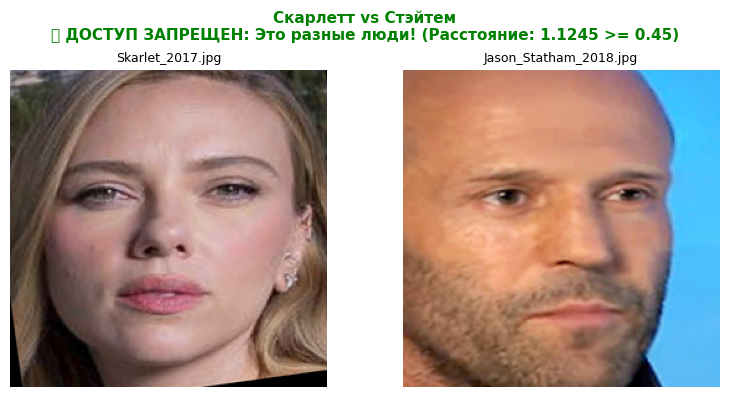

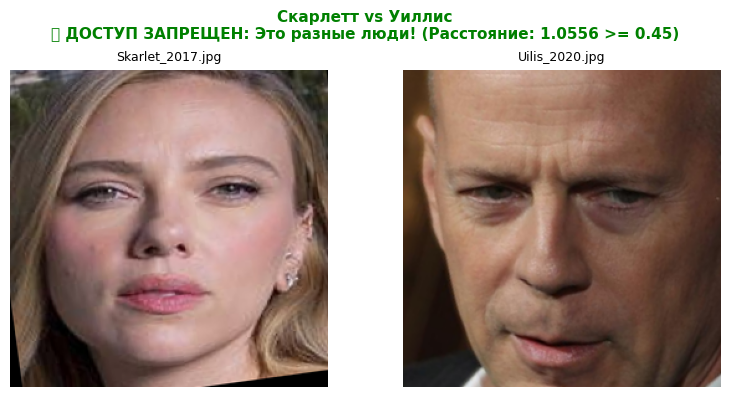

/tmp/ipykernel_37963/2455972822.py:49: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


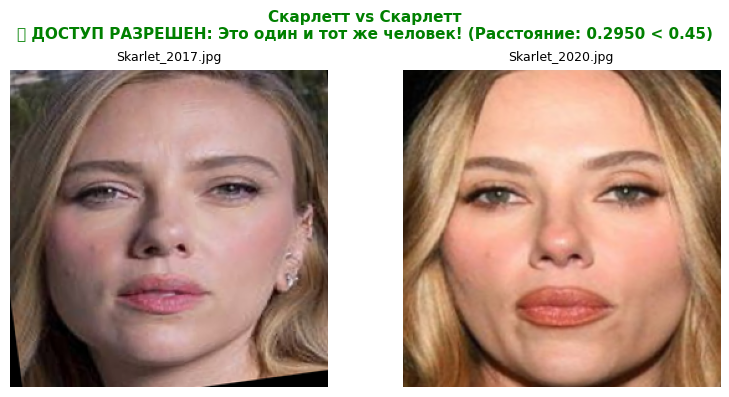

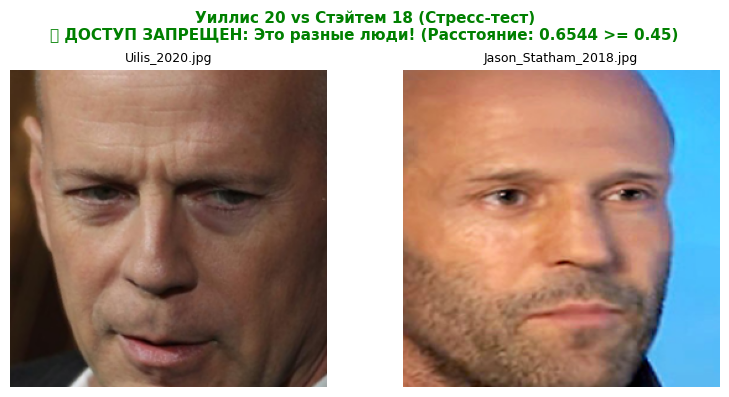

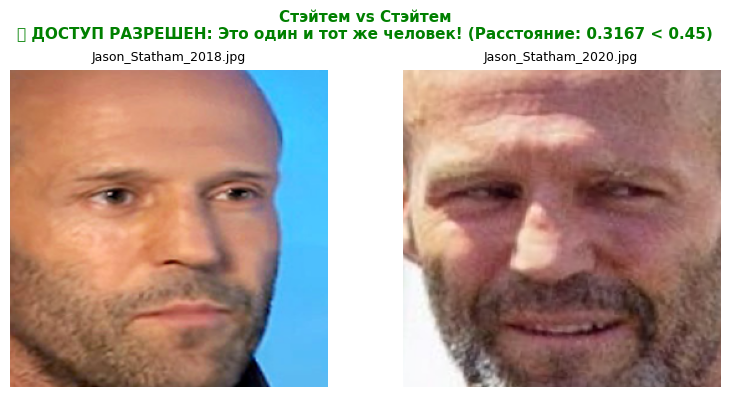

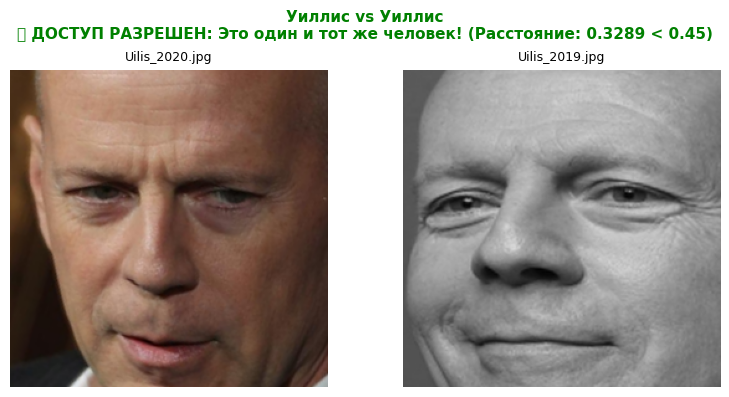

In [ ]:
base_path = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/Dataset/Image/'

img_scarlett_1 = base_path + 'Skarlet_2017.jpg'
img_scarlett_2 = base_path + 'Skarlet_2020.jpg'
img_statham_18 = base_path + 'Jason_Statham_2018.jpg'
img_statham_2  = base_path + 'Jason_Statham_2020.jpg'
img_willis_20  = base_path + 'Uilis_2020.jpg'
img_willis_2   = base_path + 'Uilis_2019.jpg'

# Список из 6 обязательных пар для визуального контроля
# Формат: (Фото 1, Фото 2, Ожидаемый вердикт True/False)
pairs_to_visualize = [
    (img_scarlett_1, img_statham_18, False, "Скарлетт vs Стэйтем"),
    (img_scarlett_1, img_willis_20,  False, "Скарлетт vs Уиллис"),
    (img_scarlett_1, img_scarlett_2, True,  "Скарлетт vs Скарлетт"),
    (img_willis_20,  img_statham_18, False, "Уиллис 20 vs Стэйтем 18 (Стресс-тест)"),
    (img_statham_18, img_statham_2,  True,  "Стэйтем vs Стэйтем"),
    (img_willis_20,  img_willis_2,   True,  "Уиллис vs Уиллис")
]

print("==========================================================")
print("📸 ЧАСТЬ 1: ОТРИСОВКА 6 ОБЯЗАТЕЛЬНЫХ СРАВНЕНИЙ")
print("==========================================================")

for p1, p2, expected, title in pairs_to_visualize:
    try:
        # Запускаем верификацию
        res = verify_two_faces(p1, p2, detector_mtcnn, model_hourglass, model_arcface, device, threshold=0.45)

        # Получаем кропы лиц для отрисовки
        crop_1 = run_face_recognition_pipeline(p1, detector_mtcnn, model_hourglass, model_arcface, device)[0]['aligned_face']
        crop_2 = run_face_recognition_pipeline(p2, detector_mtcnn, model_hourglass, model_arcface, device)[0]['aligned_face']

        # Отрисовка
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(crop_1)
        axes[0].set_title(os.path.basename(p1), fontsize=9)
        axes[0].axis('off')

        axes[1].imshow(crop_2)
        axes[1].set_title(os.path.basename(p2), fontsize=9)
        axes[1].axis('off')

        # Подсвечиваем заголовок зеленым при совпадении с ожиданиями и красным при ошибке
        is_correct = (res['is_same'] == expected)
        color_title = 'green' if is_correct else 'red'

        plt.suptitle(f"{title}\n{res['status']}", fontsize=11, color=color_title, fontweight='bold')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"[ПРОПУСК] Не удалось обработать пару {title}: {e}")

А тут я решил пробежаться по всем парам и подсчитать, так сказать, номинальную Accuracy конечно для реальной статистики нужны большие данные, но и так достаточно наглядно.

In [ ]:
print("\n==========================================================")
print("📊 ЧАСТЬ 2: СБОР СТАТИСТИКИ И РАСЧЕТ СУММАРНОЙ ACCURACY")
print("==========================================================")

# Собираем список всех изображений в твоей папке
all_images = [os.path.join(base_path, f) for f in os.listdir(base_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Всего обнаружено файлов для анализа: {len(all_images)}")

correct_predictions = 0
total_pairs = 0

# Функция для грубого определения — один ли это человек по имени файла
# Предполагаем, что имя файла содержит подстроку 'scarlett', 'statham' или 'willis'
def get_person_label(filename):
    fn = filename.lower()
    if 'scarlett' in fn or 'johansson' in fn: return 'scarlett'
    if 'statham' in fn: return 'statham'
    if 'willis' in fn: return 'willis'
    return filename # Если имя кастомное

# Попарно перебираем все файлы (комбинации без повторений)
for i in range(len(all_images)):
    for j in range(i + 1, len(all_images)):
        file1 = all_images[i]
        file2 = all_images[j]

        ground_truth_same = (get_person_label(file1) == get_person_label(file2))

        try:
            res = verify_two_faces(file1, file2, detector_mtcnn, model_hourglass, model_arcface, device, threshold=0.45)

            if res['is_same'] == ground_truth_same:
                correct_predictions += 1
            total_pairs += 1

        except:
            continue

if total_pairs > 0:
    accuracy = (correct_predictions / total_pairs) * 100
    print(f"\n✅ Расчет завершен!")
    print(f"Всего успешно сопоставлено пар: {total_pairs}")
    print(f"Из них система ответила верно: {correct_predictions}")
    print(f"🎯 Итоговая псевдо-Accuracy нашего турникета: {accuracy:.2f}%")
else:
    print("[WARNING] Не удалось собрать пары для расчета статистики.")


📊 ЧАСТЬ 2: СБОР СТАТИСТИКИ И РАСЧЕТ СУММАРНОЙ ACCURACY
Всего обнаружено файлов для анализа: 12

✅ Расчет завершен!
Всего успешно сопоставлено пар: 66
Из них система ответила верно: 47
🎯 Итоговая псевдо-Accuracy нашего турникета: 71.21%
